# Solving the Griewank Function

This notebook implements and compares four optimization strategies on the Griewank function:
- **Random Search**
- **Gradient Descent** (numerical gradients)
- **CMA-ES** (Covariance Matrix Adaptation Evolution Strategy)
- **Differential Evolution** (scipy)

We run each optimizer across four dimensionalities matching the game levels:
- Level 1: 1D (budget 40)
- Level 2: 2D (budget 35)
- Level 3: 5D (budget 30)
- Level 4: 10D (budget 25)

The Griewank function: $f(x) = 1 + \frac{1}{4000}\sum_i x_i^2 - \prod_i \cos\left(\frac{x_i}{\sqrt{i}}\right)$

Global minimum: $f(0, 0, \ldots, 0) = 0$

In [1]:
import math
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import differential_evolution

try:
    import cma
except ImportError:
    print('Installing cma...')
    import subprocess
    subprocess.check_call(['pip', 'install', 'cma'])
    import cma

Matplotlib is building the font cache; this may take a moment.


## 1. Griewank Function (matching JS exactly)

This implementation matches `frontend/js/griewank.js` and `backend/griewank.py` exactly.

In [2]:
def griewank(x):
    """Evaluate the Griewank function for an N-dimensional input.
    
    Matches frontend/js/griewank.js and backend/griewank.py exactly.
    
    f(x) = 1 + (1/4000) * sum(xi^2) - prod(cos(xi / sqrt(i+1)))
    
    Args:
        x: Array-like of input values (one per dimension).
    Returns:
        The function value (0 at the global minimum).
    """
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n == 0:
        return 0.0
    
    sum_sq = np.sum(x * x)
    indices = np.arange(1, n + 1, dtype=float)
    prod_cos = np.prod(np.cos(x / np.sqrt(indices)))
    
    return 1.0 + sum_sq / 4000.0 - prod_cos


# Verify: global minimum at origin should be 0
assert griewank([0.0]) == 0.0
assert griewank([0.0, 0.0]) == 0.0
assert griewank([0.0] * 10) == 0.0

# Verify: always non-negative in [-5, 5]
rng = np.random.default_rng(42)
for _ in range(1000):
    test_x = rng.uniform(-5, 5, size=5)
    assert griewank(test_x) >= 0.0

print('Griewank function verified: matches specification.')

Griewank function verified: matches specification.


## 2. Level Configuration

In [3]:
LEVELS = [
    {'id': 1, 'dimensions': 1, 'budget': 40, 'name': 'Level 1 (1D)'},
    {'id': 2, 'dimensions': 2, 'budget': 35, 'name': 'Level 2 (2D)'},
    {'id': 3, 'dimensions': 5, 'budget': 30, 'name': 'Level 3 (5D)'},
    {'id': 4, 'dimensions': 10, 'budget': 25, 'name': 'Level 4 (10D)'},
]

SEARCH_RANGE = (-5.0, 5.0)

print('Levels configured:')
for lvl in LEVELS:
    print(f"  {lvl['name']}: {lvl['dimensions']}D, budget={lvl['budget']}")

Levels configured:
  Level 1 (1D): 1D, budget=40
  Level 2 (2D): 2D, budget=35
  Level 3 (5D): 5D, budget=30
  Level 4 (10D): 10D, budget=25


## 3. Optimizer Implementations

Each optimizer records a trace: list of `(position, value)` at each evaluation.

In [4]:
def random_search(dims, budget, seed=42):
    """Random search: sample uniformly in [-5, 5]^dims, track best."""
    rng = np.random.default_rng(seed)
    trace = []
    best_pos = None
    best_val = float('inf')
    
    for _ in range(budget):
        pos = rng.uniform(SEARCH_RANGE[0], SEARCH_RANGE[1], size=dims)
        val = griewank(pos)
        if val < best_val:
            best_val = val
            best_pos = pos.copy()
        trace.append({'position': pos.tolist(), 'value': float(val)})
    
    return trace, best_pos.tolist(), float(best_val)


def gradient_descent(dims, budget, seed=42, lr=0.1, eps=1e-5):
    """Gradient descent with numerical gradients."""
    rng = np.random.default_rng(seed)
    # Start from a random point (not too close to origin)
    pos = rng.uniform(-3.0, 3.0, size=dims)
    trace = []
    
    val = griewank(pos)
    trace.append({'position': pos.tolist(), 'value': float(val)})
    
    for step in range(budget - 1):
        # Numerical gradient (central difference)
        grad = np.zeros(dims)
        for i in range(dims):
            pos_plus = pos.copy()
            pos_minus = pos.copy()
            pos_plus[i] += eps
            pos_minus[i] -= eps
            grad[i] = (griewank(pos_plus) - griewank(pos_minus)) / (2 * eps)
        
        # Update with clipping to search range
        pos = pos - lr * grad
        pos = np.clip(pos, SEARCH_RANGE[0], SEARCH_RANGE[1])
        
        val = griewank(pos)
        trace.append({'position': pos.tolist(), 'value': float(val)})
        
        # Reduce learning rate over time
        lr *= 0.98
    
    return trace, pos.tolist(), float(val)


def cma_es_optimize(dims, budget, seed=42):
    """CMA-ES optimization using the cma library."""
    rng = np.random.default_rng(seed)
    x0 = rng.uniform(-3.0, 3.0, size=dims).tolist()
    sigma0 = 2.0
    trace = []
    
    # Track evaluations via a wrapper
    eval_count = [0]
    
    def objective(x):
        val = griewank(x)
        if eval_count[0] < budget:
            trace.append({'position': list(x), 'value': float(val)})
            eval_count[0] += 1
        return val
    
    opts = {
        'maxfevals': budget,
        'bounds': [SEARCH_RANGE[0], SEARCH_RANGE[1]],
        'seed': seed,
        'verbose': -9,  # suppress output
        'popsize': max(4, min(budget // 3, 10)),
    }
    
    es = cma.CMAEvolutionStrategy(x0, sigma0, opts)
    
    while not es.stop() and eval_count[0] < budget:
        solutions = es.ask()
        fitness = [objective(s) for s in solutions]
        es.tell(solutions, fitness)
    
    # Trim trace to budget
    trace = trace[:budget]
    
    if trace:
        best_idx = min(range(len(trace)), key=lambda i: trace[i]['value'])
        return trace, trace[best_idx]['position'], trace[best_idx]['value']
    else:
        return [{'position': x0, 'value': griewank(x0)}], x0, griewank(x0)


def diff_evolution_optimize(dims, budget, seed=42):
    """Differential evolution using scipy.optimize."""
    trace = []
    eval_count = [0]
    
    def objective(x):
        val = griewank(x)
        if eval_count[0] < budget:
            trace.append({'position': x.tolist(), 'value': float(val)})
            eval_count[0] += 1
        return val
    
    bounds = [(SEARCH_RANGE[0], SEARCH_RANGE[1])] * dims
    
    # Use small population to stay within budget
    popsize = max(2, min(budget // 4, 5))
    
    result = differential_evolution(
        objective,
        bounds=bounds,
        maxiter=budget,
        seed=seed,
        popsize=popsize,
        tol=1e-10,
        init='latinhypercube',
    )
    
    # Trim trace to budget
    trace = trace[:budget]
    
    if trace:
        best_idx = min(range(len(trace)), key=lambda i: trace[i]['value'])
        return trace, trace[best_idx]['position'], trace[best_idx]['value']
    else:
        return [{'position': result.x.tolist(), 'value': float(result.fun)}], result.x.tolist(), float(result.fun)

## 4. Run All Optimizers Across All Levels

In [5]:
OPTIMIZERS = {
    'random_search': random_search,
    'gradient_descent': gradient_descent,
    'cma_es': cma_es_optimize,
    'differential_evolution': diff_evolution_optimize,
}

# Store all results: results[level_id][optimizer_name] = {trace, best_pos, best_val}
results = {}

for level in LEVELS:
    level_id = level['id']
    dims = level['dimensions']
    budget = level['budget']
    results[level_id] = {}
    
    print(f"\n{'='*60}")
    print(f"{level['name']} — {dims}D, budget={budget}")
    print(f"{'='*60}")
    
    for name, optimizer in OPTIMIZERS.items():
        trace, best_pos, best_val = optimizer(dims, budget)
        results[level_id][name] = {
            'trace': trace,
            'best_position': best_pos,
            'best_value': best_val,
        }
        print(f"  {name:25s} -> best_value = {best_val:.6f}")

print(f"\n{'='*60}")
print('All optimizers complete.')


Level 1 (1D) — 1D, budget=40
  random_search             -> best_value = 0.029382
  gradient_descent          -> best_value = 0.008594
  cma_es                    -> best_value = 0.000201
  differential_evolution    -> best_value = 0.000261

Level 2 (2D) — 2D, budget=35
  random_search             -> best_value = 0.075500
  gradient_descent          -> best_value = 0.021842
  cma_es                    -> best_value = 0.051673
  differential_evolution    -> best_value = 0.102151

Level 3 (5D) — 5D, budget=30
  random_search             -> best_value = 0.429446
  gradient_descent          -> best_value = 0.978671
  cma_es                    -> best_value = 0.708310
  differential_evolution    -> best_value = 0.554837

Level 4 (10D) — 10D, budget=25
  random_search             -> best_value = 1.003004
  gradient_descent          -> best_value = 1.008928
  cma_es                    -> best_value = 0.933284
  differential_evolution    -> best_value = 0.993800

All optimizers complete.


## 5. Visualise Solver Paths (1D Landscape)

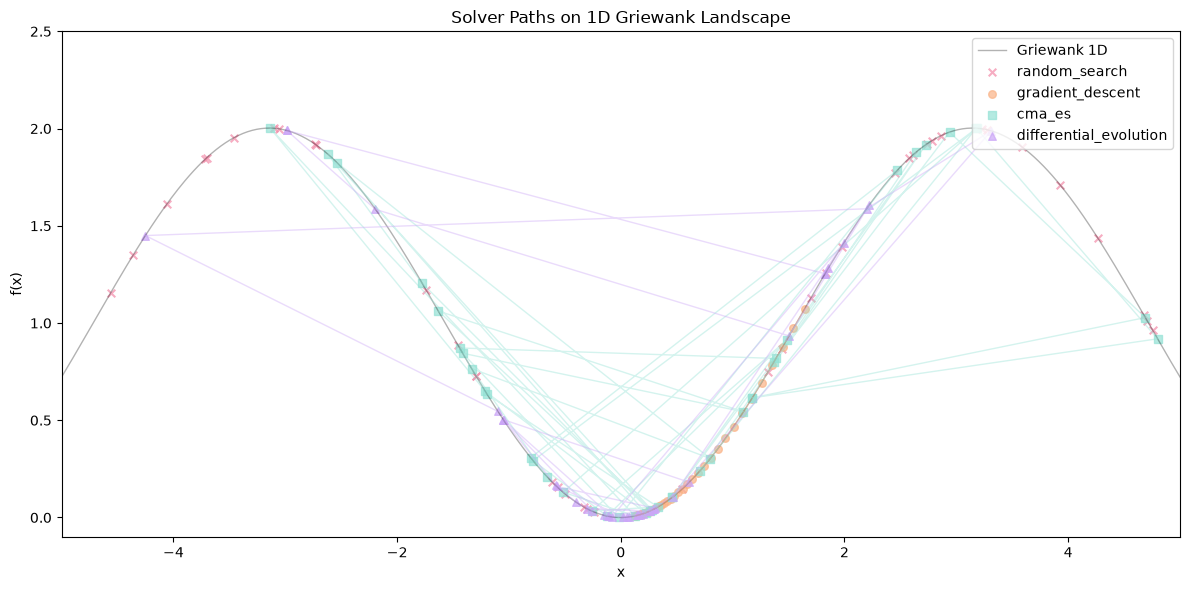

In [6]:
# Plot 1D landscape with solver paths
x_range = np.linspace(-5, 5, 500)
y_values = [griewank([xi]) for xi in x_range]

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.plot(x_range, y_values, 'k-', alpha=0.3, linewidth=1, label='Griewank 1D')

colors = {'random_search': '#f38ba8', 'gradient_descent': '#fab387',
           'cma_es': '#94e2d5', 'differential_evolution': '#cba6f7'}
markers = {'random_search': 'x', 'gradient_descent': 'o',
           'cma_es': 's', 'differential_evolution': '^'}

for name, data in results[1].items():
    trace = data['trace']
    xs = [t['position'][0] for t in trace]
    ys = [t['value'] for t in trace]
    ax.scatter(xs, ys, c=colors[name], marker=markers[name], s=30, alpha=0.7, label=name)
    # Draw path for non-random methods
    if name != 'random_search':
        ax.plot(xs, ys, c=colors[name], alpha=0.4, linewidth=1)

ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Solver Paths on 1D Griewank Landscape')
ax.legend(loc='upper right')
ax.set_xlim(-5, 5)
ax.set_ylim(-0.1, 2.5)
plt.tight_layout()
plt.show()

## 6. Visualise Solver Paths (2D Landscape)

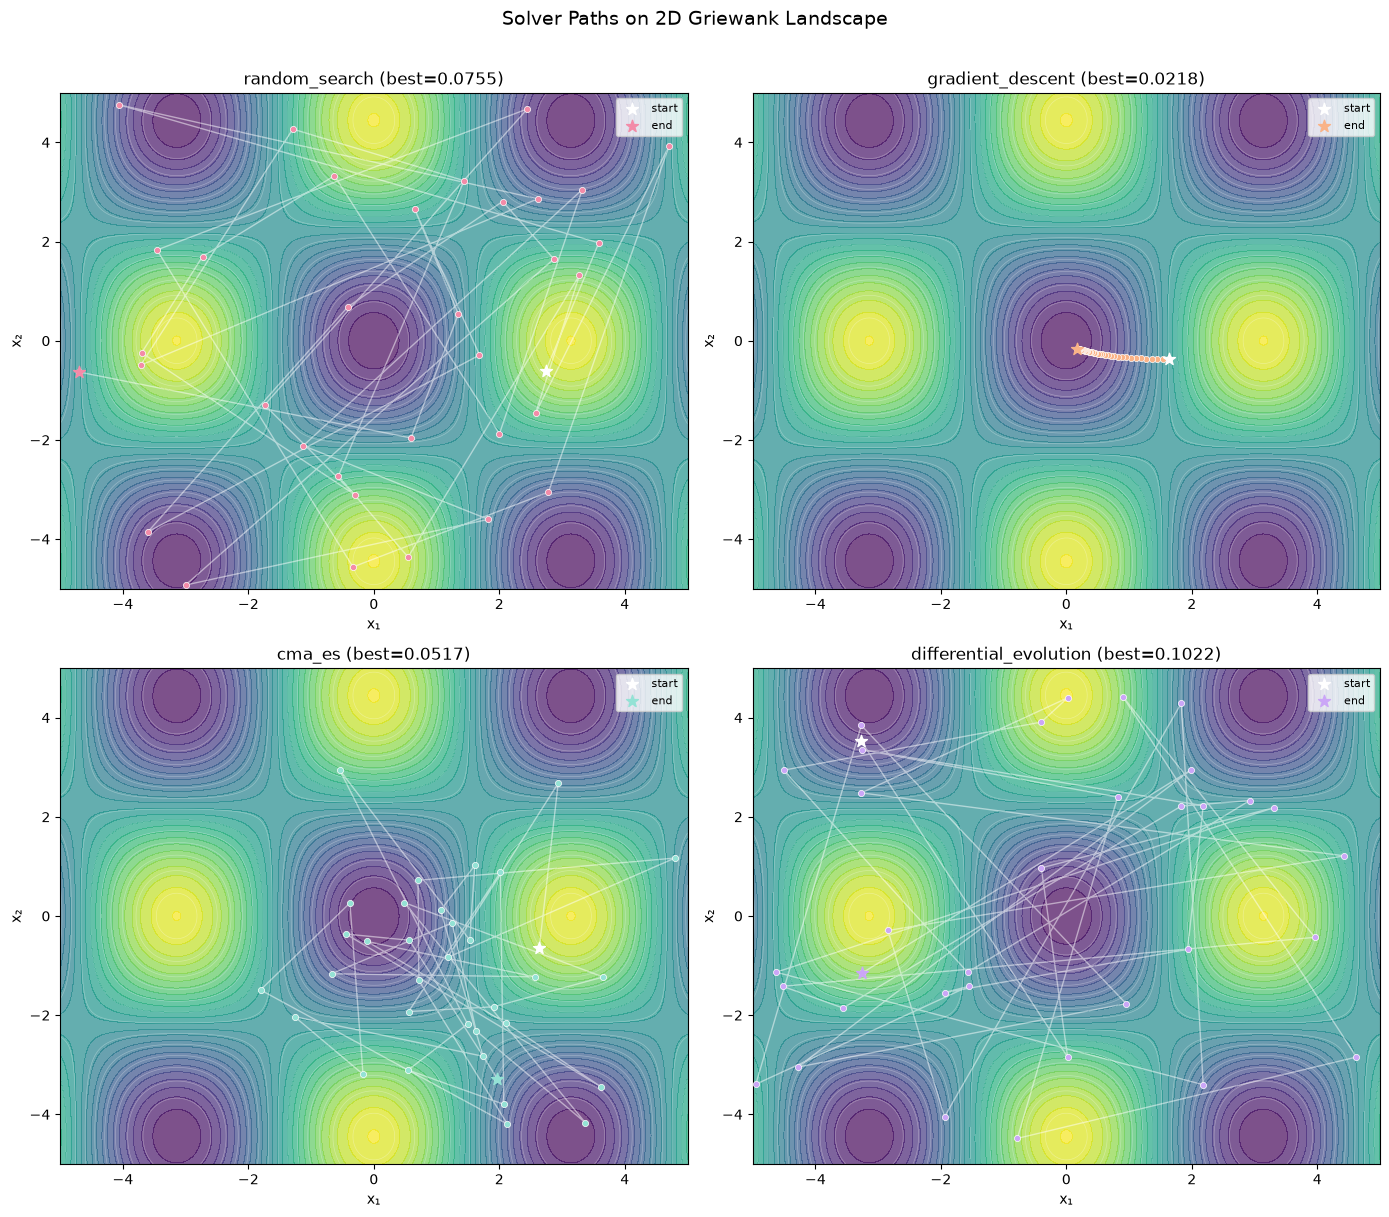

In [7]:
# Plot 2D landscape with solver paths
x1_range = np.linspace(-5, 5, 200)
x2_range = np.linspace(-5, 5, 200)
X1, X2 = np.meshgrid(x1_range, x2_range)
Z = np.array([[griewank([x1, x2]) for x1 in x1_range] for x2 in x2_range])

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (name, data) in enumerate(results[2].items()):
    ax = axes[idx]
    # Contour plot
    c = ax.contourf(X1, X2, Z, levels=30, cmap='viridis', alpha=0.7)
    ax.contour(X1, X2, Z, levels=15, colors='white', alpha=0.3, linewidths=0.5)
    
    # Solver path
    trace = data['trace']
    xs = [t['position'][0] for t in trace]
    ys = [t['position'][1] for t in trace]
    
    ax.plot(xs, ys, 'w-', alpha=0.5, linewidth=1)
    ax.scatter(xs, ys, c=colors[name], s=20, zorder=5, edgecolors='white', linewidth=0.5)
    ax.scatter(xs[0], ys[0], c='white', s=80, marker='*', zorder=6, label='start')
    ax.scatter(xs[-1], ys[-1], c=colors[name], s=80, marker='*', zorder=6, label='end')
    
    ax.set_title(f"{name} (best={data['best_value']:.4f})")
    ax.set_xlabel('x₁')
    ax.set_ylabel('x₂')
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle('Solver Paths on 2D Griewank Landscape', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. Performance Comparison Across Dimensions

Level        Optimizer                 Best Value   Budget  
------------------------------------------------------------
Level 1 (1D) random_search             0.029382     40      
Level 1 (1D) gradient_descent          0.008594     40      
Level 1 (1D) cma_es                    0.000201     40      
Level 1 (1D) differential_evolution    0.000261     40      

Level 2 (2D) random_search             0.075500     35      
Level 2 (2D) gradient_descent          0.021842     35      
Level 2 (2D) cma_es                    0.051673     35      
Level 2 (2D) differential_evolution    0.102151     35      

Level 3 (5D) random_search             0.429446     30      
Level 3 (5D) gradient_descent          0.978671     30      
Level 3 (5D) cma_es                    0.708310     30      
Level 3 (5D) differential_evolution    0.554837     30      

Level 4 (10D) random_search             1.003004     25      
Level 4 (10D) gradient_descent          1.008928     25      
Level 4 (10D) cma_e

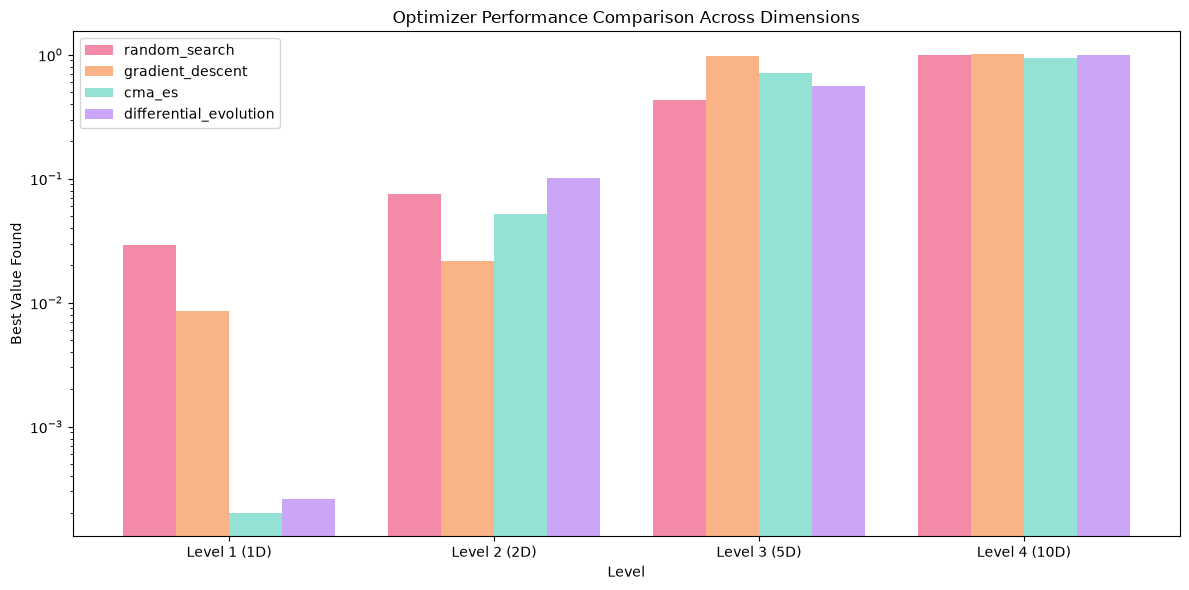

In [8]:
# Build comparison table
print(f"{'Level':<12} {'Optimizer':<25} {'Best Value':<12} {'Budget':<8}")
print('-' * 60)

comparison_data = []

for level in LEVELS:
    level_id = level['id']
    for name in OPTIMIZERS:
        best_val = results[level_id][name]['best_value']
        print(f"{level['name']:<12} {name:<25} {best_val:<12.6f} {level['budget']:<8}")
        comparison_data.append({
            'level': level_id,
            'dims': level['dimensions'],
            'optimizer': name,
            'best_value': best_val,
            'budget': level['budget'],
        })
    print()

# Bar chart comparison
fig, ax = plt.subplots(figsize=(12, 6))

level_names = [l['name'] for l in LEVELS]
x = np.arange(len(LEVELS))
width = 0.2

for i, name in enumerate(OPTIMIZERS):
    values = [results[l['id']][name]['best_value'] for l in LEVELS]
    ax.bar(x + i * width, values, width, label=name, color=colors[name])

ax.set_xlabel('Level')
ax.set_ylabel('Best Value Found')
ax.set_title('Optimizer Performance Comparison Across Dimensions')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(level_names)
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

## 8. Save Optimizer Traces

Save traces in a format that `export_ghost.py` can use to generate ghost JSON files.

In [9]:
# Save as both pickle (for Python reuse) and JSON (portable)
output_dir = Path('output')
output_dir.mkdir(exist_ok=True)

# Structure for export_ghost.py
export_data = {}
for level in LEVELS:
    level_id = level['id']
    export_data[level_id] = {
        'level': level_id,
        'dimensions': level['dimensions'],
        'budget': level['budget'],
        'optimizers': {}
    }
    for name in OPTIMIZERS:
        r = results[level_id][name]
        export_data[level_id]['optimizers'][name] = {
            'trace': r['trace'],
            'best_position': r['best_position'],
            'best_value': r['best_value'],
        }

# Save as JSON
json_path = output_dir / 'optimizer_traces.json'
with open(json_path, 'w') as f:
    json.dump(export_data, f, indent=2)
print(f'Saved JSON traces to {json_path}')

# Save as pickle
pickle_path = output_dir / 'optimizer_traces.pkl'
with open(pickle_path, 'wb') as f:
    pickle.dump(export_data, f)
print(f'Saved pickle traces to {pickle_path}')

print(f'\nTrace summary:')
for level_id, data in export_data.items():
    print(f"  Level {level_id} ({data['dimensions']}D):")
    for name, opt_data in data['optimizers'].items():
        print(f"    {name}: {len(opt_data['trace'])} evals, best={opt_data['best_value']:.6f}")

Saved JSON traces to output/optimizer_traces.json
Saved pickle traces to output/optimizer_traces.pkl

Trace summary:
  Level 1 (1D):
    random_search: 40 evals, best=0.029382
    gradient_descent: 40 evals, best=0.008594
    cma_es: 40 evals, best=0.000201
    differential_evolution: 40 evals, best=0.000261
  Level 2 (2D):
    random_search: 35 evals, best=0.075500
    gradient_descent: 35 evals, best=0.021842
    cma_es: 35 evals, best=0.051673
    differential_evolution: 35 evals, best=0.102151
  Level 3 (5D):
    random_search: 30 evals, best=0.429446
    gradient_descent: 30 evals, best=0.978671
    cma_es: 30 evals, best=0.708310
    differential_evolution: 30 evals, best=0.554837
  Level 4 (10D):
    random_search: 25 evals, best=1.003004
    gradient_descent: 25 evals, best=1.008928
    cma_es: 25 evals, best=0.933284
    differential_evolution: 25 evals, best=0.993800


## 9. Select Best Optimizer per Level for Ghost Data

Pick the best-performing optimizer for each level to use as the AI ghost.

In [10]:
# Select best optimizer per level (preferring CMA-ES for the ghost, as it's pedagogically interesting)
ghost_selections = {}

for level in LEVELS:
    level_id = level['id']
    # Find best optimizer by final value
    best_name = min(results[level_id], key=lambda n: results[level_id][n]['best_value'])
    ghost_selections[level_id] = {
        'algorithm': best_name,
        'best_value': results[level_id][best_name]['best_value'],
    }
    print(f"Level {level_id}: Best optimizer = {best_name} (value={results[level_id][best_name]['best_value']:.6f})")

print('\nThese will be exported as ghost data by export_ghost.py')

Level 1: Best optimizer = cma_es (value=0.000201)
Level 2: Best optimizer = gradient_descent (value=0.021842)
Level 3: Best optimizer = random_search (value=0.429446)
Level 4: Best optimizer = cma_es (value=0.933284)

These will be exported as ghost data by export_ghost.py
